epoch: 0 loss: 1.7853
epoch: 50 loss: 1.3821
epoch: 100 loss: 1.21
epoch: 150 loss: 1.1179
epoch: 200 loss: 1.0608
epoch: 250 loss: 1.0215
epoch: 300 loss: 0.9925
epoch: 350 loss: 0.9701
epoch: 400 loss: 0.9519
epoch: 450 loss: 0.9369
epoch: 500 loss: 0.924
epoch: 550 loss: 0.9129
epoch: 600 loss: 0.9031
epoch: 650 loss: 0.8944
epoch: 700 loss: 0.8865
epoch: 750 loss: 0.8794
epoch: 800 loss: 0.8729
epoch: 850 loss: 0.8669
epoch: 900 loss: 0.8614
epoch: 950 loss: 0.8562
epoch: 1000 loss: 0.8514
epoch: 1050 loss: 0.8469
epoch: 1100 loss: 0.8427
epoch: 1150 loss: 0.8387

Train Accuracy: 0.65
Test Accuracy: 0.7222222222222222


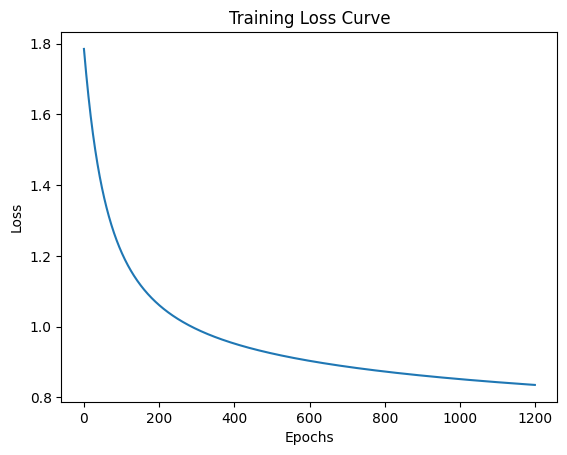

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

np.random.seed(0)

data = pd.read_csv("glass.csv")

if "Id" in data.columns:
    data = data.drop("Id", axis=1)

X = data.drop("Type", axis=1).values
y = data["Type"].values

classes = np.unique(y)
class_map = {c:i for i,c in enumerate(classes)}
y = np.array([class_map[i] for i in y])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

n_samples, n_features = X_train.shape
n_classes = len(classes)

W = np.random.randn(n_features, n_classes) * 0.01
b = np.zeros(n_classes)

lr = 0.03
epochs = 1200

loss_history = []

def softmax(z):
    z = z - np.max(z, axis=1, keepdims=True)
    exp = np.exp(z)
    return exp / np.sum(exp, axis=1, keepdims=True)

def one_hot(y, c):
    m = len(y)
    mat = np.zeros((m,c))
    mat[np.arange(m), y] = 1
    return mat

Y_train = one_hot(y_train, n_classes)

for epoch in range(epochs):

    logits = np.dot(X_train, W) + b
    probs = softmax(logits)

    loss = -np.mean(np.sum(Y_train * np.log(probs + 1e-9), axis=1))
    loss_history.append(loss)

    error = probs - Y_train

    dW = np.dot(X_train.T, error) / n_samples
    db = np.sum(error, axis=0) / n_samples

    W -= lr * dW
    b -= lr * db

    if epoch % 50 == 0:
        print("epoch:", epoch, "loss:", round(loss,4))

train_pred = np.argmax(softmax(np.dot(X_train,W)+b), axis=1)
test_pred = np.argmax(softmax(np.dot(X_test,W)+b), axis=1)

print("\nTrain Accuracy:", accuracy_score(y_train, train_pred))
print("Test Accuracy:", accuracy_score(y_test, test_pred))

plt.figure()
plt.plot(loss_history)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.show()